
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_05_reg_multivariada_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5: Regresión multivariada

Supongamos que tenemos un conjunto de características $X = X_1, X_2,\ldots,X_j,\ldots,X_n$ para realizar una predicción $y$ con valores esperados $\hat{y}$.

Cada $X_j$ puede escribirse como:

$X_1 = x_1^{(1)},x_1^{(2)},x_1^{(3)},\ldots,x_1^{(m)}$,

$X_2 = x_2^{(1)},x_2^{(2)},x_2^{(3)},\ldots,x_2^{(m)}$,

.

.

.

$X_n = x_n^{(1)},x_n^{(2)},x_n^{(3)},\ldots,x_n^{(m)}$.

Siendo $n$ el número de características y $m$ el número de datos,
$\hat{y} = \hat{y}^{(1)},\hat{y}^{(2)},\ldots,\hat{y}^{(m)}$ el conjunto de valores etiquetados, y
$y = y^{(1)},y^{(2)},\ldots,y^{(m)}$ los valores predichos por un modelo.

Lo anterior puede resumirse como:

| Training | $\hat{y}$ | $X_1$ | $X_2$ | . | . | . | . | $X_n$ |
|--------|--------|------|------|---|---|---|---|------|
| 1 | $\hat{y}^{(1)}$ | $x_1^{(1)}$ | $x_2^{(1)}$ | . | . | . | . | $x_n^{(1)}$ |
| 2 | $\hat{y}^{(2)}$ | $x_1^{(2)}$ | $x_2^{(2)}$ | . | . | . | . | $x_n^{(2)}$ |
| . | . | . | . | . | . | . | . | . |
| . | . | . | . | . | . | . | . | . |
| . | . | . | . | . | . | . | . | . |
| m | $\hat{y}^{(m)}$ | $x_1^{(m)}$ | $x_2^{(m)}$ | . | . | . | . | $x_n^{(m)}$ |

y el modelo puede ajustarse como sigue:

Para un solo dato de entrenamiento tenemos que:

\begin{equation}
y = h(\theta_0,\theta_1,\theta_2,\ldots,\theta_n) = \theta_0 + \theta_1 x_1+\theta_2 x_2 + \theta_3 x_3 + \ldots + \theta_n x_n
\end{equation}

\begin{equation}
h_{\Theta}(x) =
[\theta_0,\theta_1,\ldots,\theta_n]
\begin{bmatrix}
1\\
x_1\\
x_2\\
\vdots\\
x_n
\end{bmatrix}
= \Theta^T X
\end{equation}

Para todo el conjunto de datos, tenemos que:

Sea $\Theta^T = [\theta_0,\theta_1,\theta_2,\ldots,\theta_n]$ una matriz $1 \times (n+1)$ y

\begin{equation}
X =
\begin{bmatrix}
1 & 1 & 1 & \cdots & 1\\
x_1^{(1)} & x_1^{(2)} & x_1^{(3)} & \cdots & x_1^{(m)}\\
x_2^{(1)} & x_2^{(2)} & x_2^{(3)} & \cdots & x_2^{(m)}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
x_n^{(1)} & x_n^{(2)} & x_n^{(3)} & \cdots & x_n^{(m)}
\end{bmatrix}_{(n+1)\times m}
\end{equation}

luego,

\begin{equation}
h = \Theta^T X
\end{equation}

con dimensión $1\times m$.

La anterior ecuación es un hiperplano en $\mathbb{R}^n$. Nótese que, en caso de tener una sola característica, la ecuación puede analizarse según lo visto en la sesión de regresión lineal.

Para la optimización, vamos a definir la función de coste $J(\theta_0,\theta_1,\theta_2,\ldots,\theta_n)$ como la función asociada a la mínima distancia entre los valores predichos y los valores esperados, según la métrica euclidiana.

- Métrica euclidiana

\begin{equation}
J(\theta_0,\theta_1,\theta_2,\ldots,\theta_n)=\frac{1}{2m} \sum_{i=1}^m \left( h_{\Theta}(x^{(i)})-\hat{y}^{(i)}\right)^2
\end{equation}

Otras métricas pueden definirse como se muestra en la siguiente referencia: [Metricas](https://jmlb.github.io/flashcards/2018/04/21/list_cost_functions_fo_neuralnets/).

Nuestro objetivo será encontrar los valores
$\Theta = (\theta_0,\theta_1,\theta_2,\ldots,\theta_n)$
que minimizan el error respecto a los valores etiquetados y esperados $\hat{y}$.

Para encontrar el $\Theta$ óptimo, se necesita minimizar la función de coste, lo que permite obtener los valores más cercanos. Esta minimización puede realizarse a través de diferentes métodos; el más conocido es el gradiente descendente.


## Gradiente descendente

Consideremos la función de coste sin realizar el promedio  de funcion de coste:
\begin{equation}
\Lambda^T =
\begin{bmatrix}
(\theta_0 1 + \theta_1 x_1^1+\theta_2 x_2^2 + \theta_3 x_3^3 +...+ \theta_n x_n^n - \hat{y}^{1})^2 \\
(\theta_0 1+ \theta_1 x_1^1+\theta_2 x_2^2 + \theta_3 x_3^3 +...+ \theta_n x_n^n - \hat{y}^{2})^2\\
.\\
.\\
.\\
(\theta_0 1 + \theta_1 x_1^m+\theta_2 x_2^m + \theta_3 x_3^m +...+ \theta_n x_n^m - \hat{y}^{m})^2\\
\end{bmatrix}
\end{equation}

$\Lambda= [\Lambda_1,\Lambda_2, ...,\Lambda_m]$

$J = \frac{1}{2m} \sum_{i}^m \Lambda_i $

El gradiente descente, puede ser escrito como:

\begin{equation}
\Delta \vec{\Theta} =  - \alpha \nabla J(\theta_0, \theta_1,...,\theta_n)
\end{equation}

escogiendo el valor j-esimo tenemos que:

\begin{equation}
\theta_j :=  - \alpha \frac{\partial J(\theta_0, \theta_1,...\theta_j...,\theta_n)}{\partial \theta_j}
\end{equation}

Aplicando lo anterior a a función de coste asociada a la métrica ecuclidiana, tenemos que:

Para $j = 0$, 


\begin{equation}
\theta_0 :=  - \alpha \frac{\partial J(\theta_0, \theta_1,...\theta_j...,\theta_n)}{\partial \theta_0} = \frac{1}{m}\alpha \sum_{i=1}^m (\theta_j X_{ji} - \hat{y}^{(i)}) 1
\end{equation}



Para $0<j<n $

\begin{equation}
\theta_j :=  - \alpha \frac{\partial J(\theta_0, \theta_1,...\theta_j...,\theta_n)}{\partial \theta_j} = \frac{1}{m} \alpha\sum_{i=1}^m (\theta_{j} X_{ji} - \hat{y}^{(i)}) X_j
\end{equation}

donde X_j es el vector de entrenamiento j-esimo.

Lo  anterior puede ser generalizado como siguem, teniendo presente que $X_0 = \vec{1}$


Para $0\leq j<n$, 

\begin{equation}
\theta_j :=  - \alpha \frac{\partial J(\theta_0, \theta_1,...\theta_j...,\theta_n)}{\partial \theta_j} = \frac{1}{m} \alpha\sum_{i=1}^m (\theta_j X_{ji} - \hat{y}^{(i)}) X_j 
\end{equation}



# Vectorizando el grandiente descendete, tenemos que:
\begin{equation}
\nabla J = \Lambda^T X
\end{equation}

Luego:

\begin{equation}
\Theta=\Theta-\alpha \nabla J
\end{equation}


### Taller

1. Para simular un conjunto de características $x_1$ , $x_2$,..., $x_n$ trabajaremos en la primera parte con dos características de datos aleatorios que presentan un plano y mostraremos que los párametros optimizados se corresponden con el valor esperado.

- Definir la ecuación  $y = 2.1*x_1 - 3.1*x_2$, y generar números aleatorios que pertenecen al plano. 

- Realizar un diagrama 3D de los puntos generados aleatoriamente. 


Nuestro objetivo será encontrar los valores $\theta_0 = 0, \theta_1=2.1, \theta_1=3.1$ que mejor ajustar el plano, empleando cálculos vectorizados.

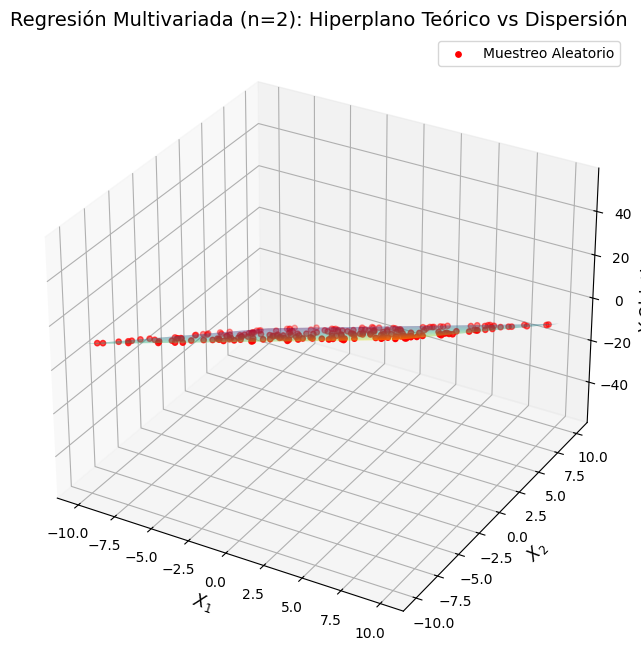

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def generar_y_graficar_plano(func_eval, n, m, span, random_state=None):
    """
    Genera un conjunto de datos multivariados a partir de un hiperplano definido
    por una función lambda y visualiza los datos en 3D si n=2.

    Args:
        func_eval (callable): Función lambda que toma una matriz de características y devuelve la variable objetivo.
        n (int): Cantidad geométrica de características (features independientes).
        m (int): Cantidad de muestras o instancias temporales/mediciones.
        span (float): Límite absoluto de dominio simétrico; x_i ∈ [-span, span].
        random_state (int, opcional): Semilla algorítmica para asegurar reproducibilidad.

    Returns:
        tuple:
            - X_raw (np.ndarray): Matriz de características (n, m).
            - Y (np.ndarray): Vector objetivo generado teóricamente (1, m).
    """
    if random_state is not None:
        np.random.seed(random_state)
        
    # Extracción de características bajo una distribución de probabilidad uniforme
    X_raw = 2 * span * np.random.random((n, m)) - span
    
    # Inyección a través de la relación funcional dictada por el ejercicio
    Y = func_eval(X_raw)
    # Reformatear estructuradamente como (1, m) en caso de que devuelva un vector plano
    Y = Y.reshape(1, -1)
    
    # Condición geométrica para graficar (Solo se puede desplegar un plano estático en 3D si n=2)
    if n == 2:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Malla teórica (Grid)
        grid_vals = np.linspace(-span, span, 50)
        x1_grid, x2_grid = np.meshgrid(grid_vals, grid_vals)
        # Vectorizar el dominio en forma (2, N)
        grid_input = np.vstack([x1_grid.ravel(), x2_grid.ravel()])
        z_grid = func_eval(grid_input).reshape(x1_grid.shape)
        
        # Trazo de la superficie (hiperplano bidimensional)
        ax.plot_surface(x1_grid, x2_grid, z_grid, alpha=0.5, cmap='viridis')
        # Trazo numérico de la dispersión de datos sintéticos
        ax.scatter(X_raw[0, :], X_raw[1, :], Y.ravel(), color='red', s=15, label='Muestreo Aleatorio')
        
        ax.set_title("Regresión Multivariada (n=2): Hiperplano Teórico vs Dispersión", fontsize=14)
        ax.set_xlabel('$X_1$', fontsize=12)
        ax.set_ylabel('$X_2$', fontsize=12)
        ax.set_zlabel('$Y$ Objetivo', fontsize=12)
        plt.legend()
        plt.show()
    else:
        print(f"[*] Dataset generado exitosamente con {n} características y {m} registros. (Sin visualización para n != 2)")
        
    return X_raw, Y

# --- Demostración del Punto 1 ---
# Definición de la ecuación requerida: y = 2.1*x1 - 3.1*x2
func_hiperplano = lambda x: 2.1 * x[0, :] - 3.1 * x[1, :]

X_raw, Y_obj = generar_y_graficar_plano(
    func_eval=func_hiperplano, 
    n=2, 
    m=200, 
    span=10.0, 
    random_state=12
)

2. Inicializar conjunto de parámetros $\Theta$ de manera aleatoria.
3. Construir la matrix X con dimensiones $(n+1, m)$, m es el numero de datos de entrenamiento y (n) el número de caracteristicas.

In [5]:
def preparar_datos_parametros(X_raw, random_state=None):
    """
    Procesa preliminarmente la matriz de características incrustando el sesgo paramétrico (bias)
    e inicializa aleatoriamente el vector columna de los pesos (Theta).

    Args:
        X_raw (np.ndarray): Matriz estocástica original multivariada (n, m).
        random_state (int, opcional): Semilla algorítmica para reproducibilidad en la generación de pesos.

    Returns:
        tuple:
            - X_ext (np.ndarray): Matriz extendida computacional con forma (n+1, m).
            - Theta (np.ndarray): Sistema de pesos matricialmente alineado con forma (n+1, 1).
    """
    if random_state is not None:
        np.random.seed(random_state)
        
    n, m = X_raw.shape
    
    # 3. Construir la Matriz X extendida apilando el intercepto o vector unitario
    # Esto soluciona la proyección lineal añadiendo matemáticamente la columna x_0 = 1 para el término independiente
    bias_row = np.ones((1, m))
    X_ext = np.vstack((bias_row, X_raw))
    
    # 2. Inicializar Theta bajo una distribución paramétrica aleatoria uniforme
    # Sus dimensiones deben ser estrictamente (n+1, 1) para alinearse al producto punto Theta^T * X
    Theta = np.random.random((n + 1, 1))
    
    return X_ext, Theta

# --- Demostración del Punto 2 y 3 ---
X_matriz, Theta_inicial = preparar_datos_parametros(X_raw, random_state=123)
print(f"Formato paramétrico de la matriz de entrada X: {X_matriz.shape}")
print(f"Formato del vector de pesos Theta: {Theta_inicial.shape}")

Formato paramétrico de la matriz de entrada X: (3, 200)
Formato del vector de pesos Theta: (3, 1)


4. Calcular la función de coste(revise cuidosamente las dimensiones de cada matriz):
 
  - $h = \Theta^{T} X $
  - $\Lambda= (h -Y) $
  - $\Lambda*= (h -Y)^2 $
  - $\Lambda= [\Lambda_1,\Lambda_2, ...,\Lambda_m]$
  - $J = \frac{1}{2m} \sum_{i}^m \Lambda_i $

In [6]:
def calcular_funcion_coste(X, Y, Theta):
    """
    Computa el escalar representativo de la función de coste por el método de
    Mínimos Cuadrados Ordinarios Modificados (MSE), de forma estrictamente purista y vectorizada.

    Args:
        X (np.ndarray): Diseño maestro matricial extendido de orden (n+1, m).
        Y (np.ndarray): Matriz real/física objetivo de orden horizontal (1, m).
        Theta (np.ndarray): Hipótesis de los parámetros del regresor (n+1, 1).

    Returns:
        float: Medida heurística del error global en la configuración actual (J).
    """
    m = X.shape[1]
    
    # Construcción de la hipótesis paramétrica del regresor. 
    # Multiplicación matricial: Theta.T (1, n+1) dot X (n+1, m) -> Produce (1, m)
    h = np.dot(Theta.T, X)
    
    # Error residual o matriz de distancias
    Lambda = h - Y
    
    # Coste J (Minimización Euclidiana promedio de toda la matriz transpuesta)
    # Se eleva .^2 internamente preservando el tipo NumPy array, iterando netamente a nivel mem cache.
    J = (1 / (2 * m)) * np.sum(Lambda ** 2)
    
    return J

# --- Demostración del Punto 4 ---
coste_inicial = calcular_funcion_coste(X_matriz, Y_obj, Theta_inicial)
print(f"Coste algorítmico residual inicial (antes de entrenamiento convergente): {coste_inicial:.4f}")

Coste algorítmico residual inicial (antes de entrenamiento convergente): 239.6700


5. Aplicar el gradiente descendente: 
  - Encontrar el gradiente.
    $\nabla J = \Lambda X.T$
  
  - Actualizar los nuevos parametros: 
    $\Theta_{n+1}=\Theta_{n}-\alpha\nabla J$

6. Iterar para encontrar los valores $\Theta$ que se ajustan el plano. 

Parámetros optimizados Theta:
[[ 3.17321569e-05]
 [ 2.09999984e+00]
 [-3.09999967e+00]]
(Espera aprox Theta = [0, 2.1, -3.1]^T para un ajuste subyacente perfecto)
Coste algorítmico logístico final (convergencia mínima lograda): 0.000000


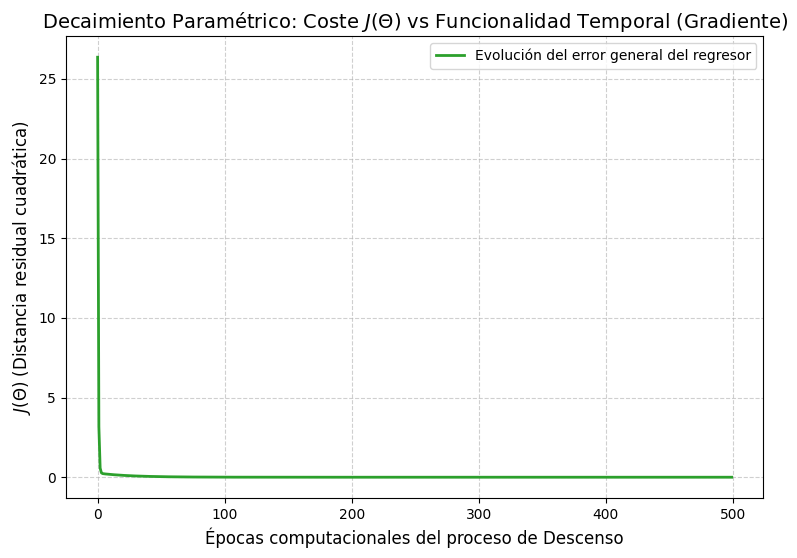

In [7]:
def entrenar_gradiente_descendente(X, Y, Theta_init, learning_rate=0.01, iteraciones=1000):
    """
    Orquesta el algoritmo generalizado de descenso de gradiente aplicable en espacios R^n.
    Optimiza el hiperparámetro Theta analizando los gradientes proyectivos y minimizando la coste.

    Args:
        X (np.ndarray): Espacio matricial computacional dinámico de covariables (n+1, m).
        Y (np.ndarray): Vector dimensional meta lograda (1, m).
        Theta_init (np.ndarray): Semilla paramétrica inicial (n+1, 1).
        learning_rate (float): 'alpha', umbral de avance algorítmico computacional o salto.
        iteraciones (int): Umbral estricto de parada por iteración forzada.

    Returns:
        tuple:
            - Theta_optimo (np.ndarray): Matriz dimensional minimizadora final (n+1, 1).
            - historial_J (list): Memoria del coste logístico J computado en R de cada iteración del regresor.
    """
    m = X.shape[1]
    
    # Restricción de inmutabilidad: Realizamos una copia en memoria de nuestra Theta entrante
    Theta = np.copy(Theta_init)
    historial_J = []
    
    for i in range(iteraciones):
        # 4. Fase de Forward Pass o Inferencia Temporal Vectorizada (1, m)
        h = np.dot(Theta.T, X)
        
        # Divergencia Paramétrica o Array de Penalización Numérica
        Lambda = h - Y # (1, m)
        
        # 5. Formulación generalizada analítica del Gradiente (Backpropagation algorítmico). 
        # (1/m) * (X * Lambda^T) -> Forma algebraícamente inversa requerida para recuperar la dimensión vertical (n+1, 1)
        gradiente = (1 / m) * np.dot(X, Lambda.T)
        
        # Aplicación directa del factor iterativo y descenso matricial
        Theta = Theta - learning_rate * gradiente
        
        # 6. Monitoreo formal del histórico de evolución penalizador
        coste_actual = calcular_funcion_coste(X, Y, Theta)
        historial_J.append(coste_actual)
        
    return Theta, historial_J

# --- Demostración de Puntos 5 y 6 ---
# Implementación explícita configurando el salto de corrección (learning_rate o alpha).
Theta_final, historico_costo = entrenar_gradiente_descendente(
    X_matriz, Y_obj, Theta_inicial, learning_rate=0.02, iteraciones=500
)

print(f"Parámetros optimizados Theta:\n{Theta_final}\n(Espera aprox Theta = [0, 2.1, -3.1]^T para un ajuste subyacente perfecto)")
print(f"Coste algorítmico logístico final (convergencia mínima lograda): {historico_costo[-1]:.6f}")

# Trazo didáctico imperativo: la verificación académica del descenso paramétrico
plt.figure(figsize=(9, 6))
plt.plot(historico_costo, color='#2ca02c', linewidth=2, label='Evolución del error general del regresor')
plt.title(r'Decaimiento Paramétrico: Coste $J(\Theta)$ vs Funcionalidad Temporal (Gradiente)', fontsize=14)
plt.xlabel('Épocas computacionales del proceso de Descenso', fontsize=12)
plt.ylabel(r'$J(\Theta)$ (Distancia residual cuadrática)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

7. Reescribir su código como una clase (ver ayuda)

```python 

import numpy as np
import matplotlib.pylab as plt
import pandas as pd
import plotly.graph_objects as go


N = 100
x1 = np.linspace(-1, 1, N)
x2 = np.linspace(-1, 1, N)
X_1, X_2 = np.meshgrid(x1, x2)
Y = 0.2 * X_1 - 0.5 * X_2


fig = go.Figure(go.Surface(x=X_1, y=X_2, z=Y))
fig.add_trace(go.Scatter3d(x=x_1, y=x_2, z=y_label, mode='markers', marker=dict(size=4, color='white')))
fig.show()


N = 100
x_1 = 2 * np.random.random(N) - 1
x_2 = 2 * np.random.random(N) - 1

y_label = 0.2 * x_1 - 0.5 * x_2 #+ 0.2*(2*np.random.random(N)-1)
df = pd.DataFrame({"x1":x_1, "x2":x_2, "y":y_label})
df["ones"]=1


X = df[["ones", "x1", "x2"]].values.T
Y = df.y.values.reshape(1, N)


Nfeatures = np.shape(X)[0]
m = np.shape(X)[1]
print(Nfeatures, m)

def model(theta, X):
  return theta.T@X

def costo(h, Y):
  J= (h-Y)**2
  return J.mean()

def update_params(theta, h, Y, learning_rate):
  """
  Gradiente descendente
  """
  grad = np.dot((h-Y), X.T).T
  theta = theta - learning_rate*grad
  return theta



theta=np.random.random(3).reshape(3, 1)
learning_rate=0.01
Niter=100
J = np.zeros(Niter)

for i in range(0, Niter):
  h = model(theta, X)
  J[i] = costo(h, Y)
  theta = update_params(theta, h, Y, learning_rate)


plt.plot(J)
```


In [8]:
class MultilinearRegresion():
    """
    Modelo Orientado a Objetos para Regresión Multivariada.
    Encapsula el comportamiento algebraico del descenso del gradiente
    aplicado a matrices extendidas X (R^{n+1}) y el vector multivariado Y.
    """
    def __init__(self, X, Y):
        """
        Inicialización del modelo.
        
        Args:
            X (np.ndarray): Matriz de características (incluyendo término de sesgo). Forma: (n+1, m).
            Y (np.ndarray): Vector objetivo. Forma: (1, m).
        """
        self.X = X
        self.Y = Y.reshape(1, -1) # Salvaguarda de redimensionamiento (1, m)
        
        # Dimensiones matemáticas:
        # Nfeatures = n + 1 (Características + vector unitario)
        # m = cantidad de datos o muestras
        Nfeatures = self.X.shape[0]
        self.m = self.X.shape[1]
        
        # Inicialización de pesos sinápticos paramétricos: dimensión vertical (n+1, 1)
        np.random.seed(42) # Fijo solo por reproducibilidad didáctica (borrar en prod)
        self.theta = np.random.random((Nfeatures, 1))
        
        # Atributo didáctico propio: Guardaremos el descenso del error 
        self.historico_J = []

    def model(self):
        """
        Fase Forward Pass: Proyección inferencial lineal sobre el hiperplano actual.
        """
        # Theta^T (1, n+1) dot X (n+1, m) -> (1, m)
        self.h = np.dot(self.theta.T, self.X)

    def costo(self):
        """
        Cálculo del penalizador objetivo J (Mínimos Cuadrados Promedio).
        Evalúa y almacena en memoria el estado computacional.
        """
        Lambda = self.h - self.Y
        self.J = (1 / (2 * self.m)) * np.sum(Lambda ** 2)
        
        # Registro orgánico del coste iterado en tiempo de ejecución
        self.historico_J.append(self.J)

    def update_params(self, learning_rate):
        """
        Gradiente descendente: Fase algorítmica Backpropagation paramétrica.
        Computa derivadas parciales y aplica regla iterativa Theta := Theta - alfa * gradJ
        """
        Lambda = self.h - self.Y # Residuo
        grad = (1 / self.m) * np.dot(self.X, Lambda.T) 
        self.theta -= learning_rate * grad

    def fit(self, learning_rate=0.01, iteraciones=100):
        """
        Orquesta el ciclo de aprendizaje completo para la convergencia espacial.
        
        Args:
            learning_rate (float): Salto algorítmico ('alpha')
            iteraciones (int): Periodos condicionales ('epochs')
        """
        self.historico_J = [] # Limpieza de caché por si se re-entrena on the fly
        
        for i in range(iteraciones):
            self.model()
            self.costo()
            self.update_params(learning_rate)

>>> Iniciando el ajuste formal de Regresión Multivariada mediante POO (Clase) <<<
Parámetros sinápticos crudos tras la inicialización (Theta_0):
[[0.37454012]
 [0.95071431]
 [0.73199394]]

--- Resultados del Aprendizaje OOP ---
Theta paramétrico subyacente tras 500 hiper-iteraciones (alpha=0.02):
[[ 1.80103148e-05]
 [ 2.09999991e+00]
 [-3.09999981e+00]]
Costo residual absoluto minimizado J(Theta): 0.000000


<>:29: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
<>:29: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
/tmp/ipykernel_56080/2474452829.py:29: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
  plt.ylabel('Costo $J(\Theta)$ residual', fontsize=12)


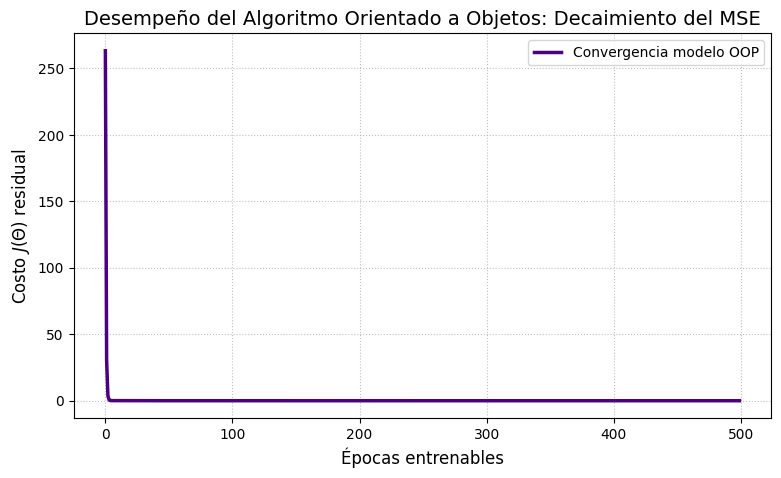

In [9]:
# --- Prueba de la Clase Orientada a Objetos ---

# 1. Utilizaremos la matriz transformada `X_matriz` (que ya contiene la columna de sesgo x_0 = 1)
# y nuestro vector de predicción objetivo `Y_obj`, tal como se plantearon en los primeros incisos.

print(">>> Iniciando el ajuste formal de Regresión Multivariada mediante POO (Clase) <<<")

# 2. Instanciación del modelo: Se inicializa el regresor enviándole la configuración actual
modelo_oop = MultilinearRegresion(X=X_matriz, Y=Y_obj)

# 3. Inspección del estado inicial paramétrico (Theta ha dictado aleatoriedad al instanciar)
print(f"Parámetros sinápticos crudos tras la inicialización (Theta_0):\n{modelo_oop.theta}\n")

# 4. Solicitud de ajuste: Invocamos el orquestador que efectúa internamente Forward, Costo y Actualización (Propagación del gradiente)
tasa_aprendizaje = 0.02
epocas = 500
modelo_oop.fit(learning_rate=tasa_aprendizaje, iteraciones=epocas)

# 5. Consolidación de información terminal post-ajuste
print("--- Resultados del Aprendizaje OOP ---")
print(f"Theta paramétrico subyacente tras {epocas} hiper-iteraciones (alpha={tasa_aprendizaje}):\n{modelo_oop.theta}")
print(f"Costo residual absoluto minimizado J(Theta): {modelo_oop.historico_J[-1]:.6f}")

# 6. Visualización didáctica de la estela de error para confirmar el decaimiento paramétrico sano usando la memoria inyectada en la lista `historico_J`
plt.figure(figsize=(9, 5))
plt.plot(modelo_oop.historico_J, color='indigo', linewidth=2.5, label='Convergencia modelo OOP')
plt.title(r'Desempeño del Algoritmo Orientado a Objetos: Decaimiento del MSE', fontsize=14)
plt.xlabel('Épocas entrenables', fontsize=12)
plt.ylabel('Costo $J(\Theta)$ residual', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.8)
plt.legend()
plt.show()

#### Nota estudiante:

Para este laboratorio probé la herramienta de OpenClaw + API_Key de Gemini 3.1 Pro Preview. El laboratorio es una generalización de lo que ya se vio en el laboratorio 4, pues tambien trabajamos con un modelo lineal pero con N features. No se me ocurrió mientras trabajaba en el qué clase de conjuntos de datos se pueden tener relaciones lineales entre las todas las features respecto al target. Después del lab 04, la implementación y entender este código fue sencillo.

Respecto a los resultados, era de esperar que las curvas de Costo vs # Epocas decayeran exponencialmente, muy rápido y que los scores y estimacion de los parámetros fueran tan buenos. Un argumento evidente es que los datos fueron directamente extraidos de un plano, sin que se les agregaran ruido extra de ningun tipo, por lo tanto estaba facil para el modelo darse cuenta de que todos eran coplanares y determinar los coeficientes de estas variables (pesos de las features).